# `cvlab` walkthrough

A 5-minute tour of the from-scratch pipeline for **CS4059 Assignment 1** (Shahoud Shahid, 23i-2515). Every operator is pure NumPy.

```bash
pip install -e ".[dev]"   # from the repo root
```

For the full, reproducible figure set run `cvlab all` instead.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from cvlab import (conv2d, conv3d, generate_gaussian_kernel_2d, unsharp_mask,
                   pool2d, max_pool_gradient, sobel_gradients, non_max_suppression,
                   double_threshold, hysteresis, canny, add_gaussian_noise, evaluate_edges)
from cvlab.datasets import get_samples
from cvlab.utils import min_max_scale

rng = np.random.default_rng(2515)
plt.rcParams['image.cmap'] = 'gray'

## Task 1 - convolution engines
The output shape always follows $O=\lfloor (I-F+2P)/S\rfloor+1$.

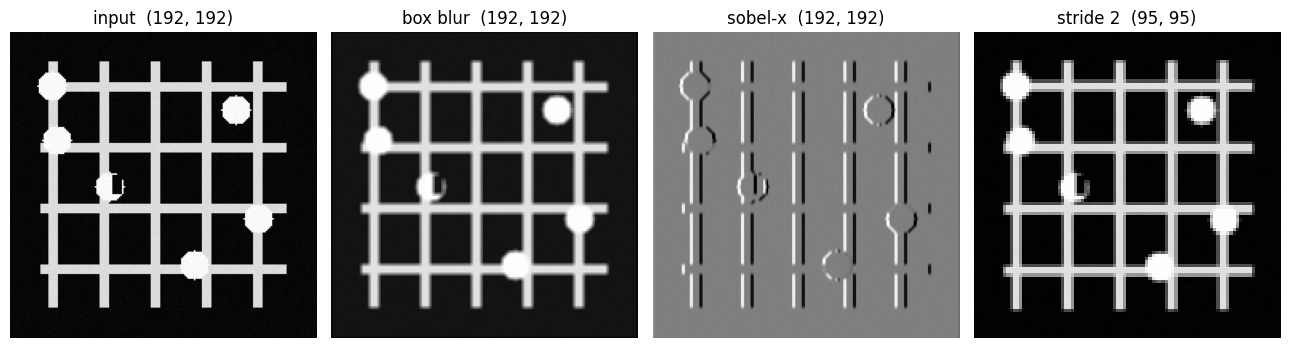

In [2]:
img = get_samples('pcb', n=1, size=192, prefer='synthetic')[0].image

identity = np.array([[0,0,0],[0,1,0],[0,0,0]], float)
assert np.allclose(conv2d(img, identity, padding='same'), img)

sobel_x = np.array([[-1,0,1],[-2,0,2],[-1,0,1]], float) / 8
box     = np.ones((3,3)) / 9

fig, ax = plt.subplots(1, 4, figsize=(13, 3.4))
for a, (name, k, s) in zip(ax, [('input', identity, 1), ('box blur', box, 1),
                                ('sobel-x', sobel_x, 1), ('stride 2', box, 2)]):
    out = conv2d(img, k, stride=s, padding='valid' if s > 1 else 'same')
    a.imshow(min_max_scale(out, 0, 255)); a.set_title(f'{name}  {out.shape}'); a.axis('off')
plt.tight_layout()

In [3]:
# conv3d: K filters over an (H, W, C) volume -> (H_out, W_out, K)
vol = np.stack([img, np.roll(img, 4, 1), np.roll(img, 4, 0)], axis=-1)
stack = np.stack([np.repeat(k[..., None], 3, -1) / 3 for k in (box, sobel_x, sobel_x.T)])
act = conv3d(vol, stack, padding='same')
print('activation volume:', act.shape)

activation volume: (192, 192, 3)


## Task 2 - Gaussian kernel, unsharp mask, pooling
The kernel sums to exactly 1; the max-pool gradient routes only to the argmax.

In [4]:
g = generate_gaussian_kernel_2d(5, sigma=1.0)
print('kernel sum =', g.sum())

block = np.array([[8., 7.], [12., 9.]])
print('max-pool(block) =', pool2d(block, (2, 2), 2, 'max')[0, 0])
print('d(out)/d(in) =\n', max_pool_gradient(block, (2, 2), 2))

kernel sum = 1.0
max-pool(block) = 12.0
d(out)/d(in) =
 [[0. 0.]
 [1. 0.]]


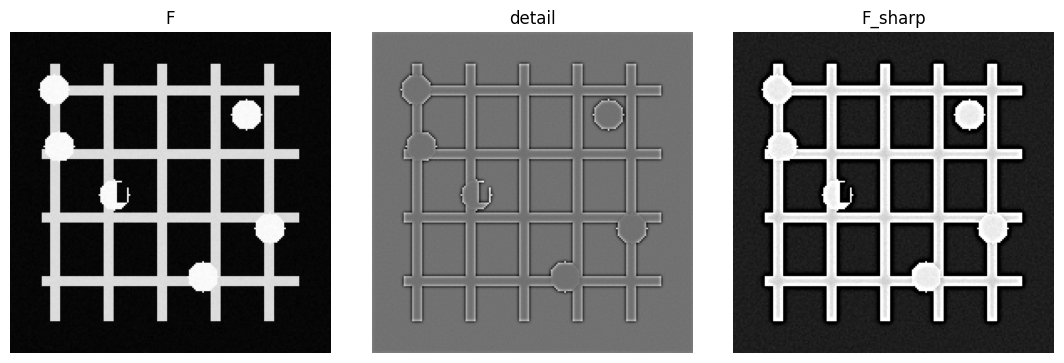

In [5]:
sharp = unsharp_mask(img, sigma=1.5, alpha=1.5)
fig, ax = plt.subplots(1, 3, figsize=(11, 3.6))
for a, (t, im) in zip(ax, [('F', img), ('detail', min_max_scale(img - conv2d(img, g, padding='same'), 0, 255)),
                           ('F_sharp', sharp)]):
    a.imshow(im); a.set_title(t); a.axis('off')
plt.tight_layout()

## Task 3 - the four-stage Canny detector
`return_stages=True` hands back every intermediate array.

metrics: {'density': 0.024533641581632654, 'n_components': 2, 'mean_component_len': 615.5, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0}


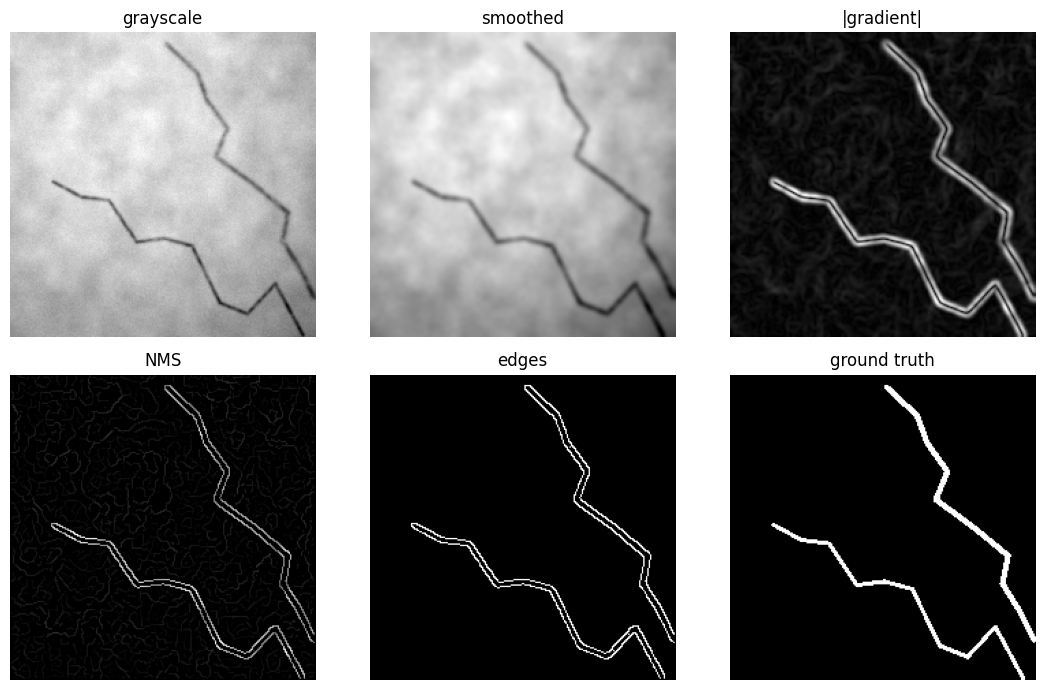

In [6]:
concrete = get_samples('concrete', n=1, size=224, prefer='synthetic')[0]
st = canny(concrete.image, sigma=1.4, low_q=0.70, high_q=0.92, return_stages=True)

panels = [('grayscale', st.gray), ('smoothed', st.smoothed),
          ('|gradient|', min_max_scale(st.magnitude, 0, 255)),
          ('NMS', min_max_scale(st.nms, 0, 255)), ('edges', st.edges),
          ('ground truth', concrete.gt_edges.astype(float))]
fig, ax = plt.subplots(2, 3, figsize=(11, 7))
for a, (t, im) in zip(ax.ravel(), panels):
    a.imshow(im); a.set_title(t); a.axis('off')
plt.tight_layout()
print('metrics:', evaluate_edges(st.edges, concrete.gt_edges).as_dict())

## Task 4 - one ablation: hysteresis vs. a single threshold
Double-threshold hysteresis links faint crack pixels without flooding on texture.

single      F1=0.791  components=56
hysteresis  F1=1.000  components=7


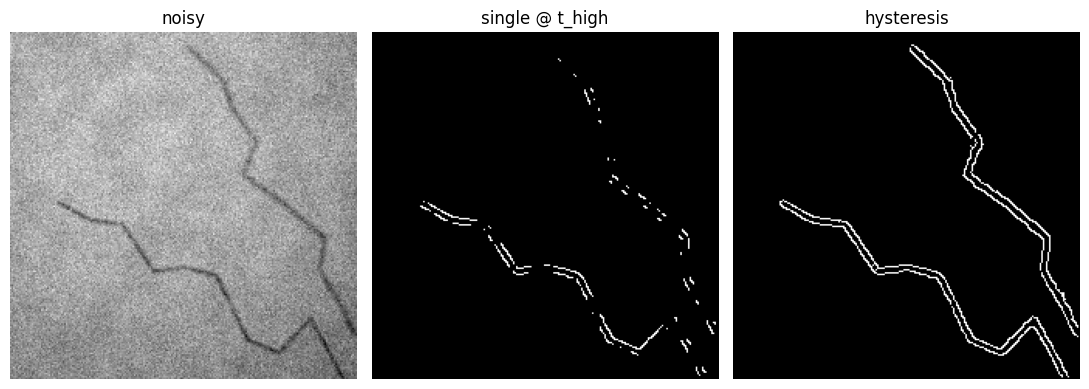

In [7]:
noisy = add_gaussian_noise(concrete.image, sigma=15, seed=2515)
*_, mag, ori = sobel_gradients(noisy, smooth_sigma=1.4)
nms = non_max_suppression(mag, ori)
from cvlab.canny import quantile_thresholds
t_lo, t_hi = quantile_thresholds(nms, 0.92, 0.97)

single = (nms >= t_hi).astype(np.uint8) * 255
strong, weak = double_threshold(nms, t_lo, t_hi)
linked = hysteresis(strong, weak)

fig, ax = plt.subplots(1, 3, figsize=(11, 3.8))
for a, (t, im) in zip(ax, [('noisy', noisy), ('single @ t_high', single), ('hysteresis', linked)]):
    a.imshow(im); a.set_title(t); a.axis('off')
plt.tight_layout()
for name, e in [('single', single), ('hysteresis', linked)]:
    m = evaluate_edges(e, concrete.gt_edges)
    print(f'{name:11s} F1={m.f1:.3f}  components={m.n_components}')

---
That is the whole public API. See `src/experiments/` for the full task drivers and `report/` for the write-up.